## Model Development

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the final EDA training dataset
train_df = pd.read_csv("../Data/train_EDA.csv")

# Load the final EDA test dataset
test_df = pd.read_csv("../Data/test_EDA.csv")

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

C:\Users\HP\AppData\Local\Temp\ipykernel_13928\2062341738.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("../Data/train_EDA.csv")


Training data shape: (421577, 20)
Test data shape: (115064, 19)


### Verifying Features and Target Variable

In [3]:
# Displaying all columns in the training dataset
print("Training columns:")
print(train_df.columns.tolist())

# Displaying all columns in the test dataset
print("\nTest columns:")
print(test_df.columns.tolist())

# Confirming that Weekly_Sales is available as the target
print("\nTarget column:", "Weekly_Sales" in train_df.columns)

Training columns:
['Store', 'Dept', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'Week', 'Quarter', 'Type_B', 'Type_C']

Test columns:
['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'Week', 'Quarter', 'Type_B', 'Type_C']

Target column: True


### Step 3 — Separate Features and Target

In [4]:
# Separate the input features from the target variable
X = train_df.drop("Weekly_Sales", axis=1)

# Store Weekly_Sales as the target variable
y = train_df["Weekly_Sales"]

# Display the shapes of features and target
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (421577, 19)
Target shape: (421577,)


### Step 4 — Time-Based Train-Validation Split

In [83]:
# Check the exact predictors used by the original model
print(X.columns.tolist())
print("Number of predictors:", X.shape[1])

['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'Week', 'Quarter', 'Type_B', 'Type_C']
Number of predictors: 19


In [5]:
# Select 2010 and 2011 for training
X_train = X[X["Year"] < 2012]
y_train = y[X["Year"] < 2012]

# Select 2012 for validation
X_val = X[X["Year"] == 2012]
y_val = y[X["Year"] == 2012]

# Display the shapes of training and validation data
print("Training features:", X_train.shape)
print("Training target:", y_train.shape)
print("Validation features:", X_val.shape)
print("Validation target:", y_val.shape)

Training features: (294132, 19)
Training target: (294132,)
Validation features: (127438, 19)
Validation target: (127438,)


In [6]:
# Check missing values in training and validation features
print("Missing values in training data:")
print(X_train.isnull().sum().sum())

print("\nMissing values in validation data:")
print(X_val.isnull().sum().sum())

Missing values in training data:
28

Missing values in validation data:
0


### Step 5 — Baseline Regression Model

In [7]:
# Import Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Create the baseline regression model
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1 
)

# Train the model using historical training data
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_

### Step 5B — Generate Validation Predictions

In [8]:
# Generate predictions for the 2012 validation data
y_pred = rf_model.predict(X_val)

# Display the first 10 predictions
print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[16252.48009479 16429.87122813 18014.92795601 18564.00933169
 23778.23502585 32540.40712822 27931.06755604 19216.87208075
 18935.53235204 19216.87208075]


## Model Evaluation


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_val, y_pred)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2626.7765352131855
RMSE: 5370.636241922466


In [10]:
# Calculate the prediction error
errors = y_val - y_pred

# Calculate the absolute error
absolute_errors = abs(errors)

# Create a copy of validation data for error analysis
error_analysis = X_val.copy()

# Add actual sales, predicted sales, and errors
error_analysis["Actual_Sales"] = y_val.values           #a single dataset containing:
                                                             #	Input features 
                                                               #	Actual sales 
                                                             #	Predicted sales 
                                                               #	Signed prediction error 
                                                                  #	Absolute prediction error 

error_analysis["Predicted_Sales"] = y_pred
error_analysis["Error"] = errors
error_analysis["Absolute_Error"] = absolute_errors

# Sort by the largest prediction errors
error_analysis = error_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
)

# Display the 10 observations with the largest errors
error_analysis.head(10)

,Store,Dept,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,...,Year,Month,Week,Quarter,Type_B,Type_C,Actual_Sales,Predicted_Sales,Error,Absolute_Error
196745,20.0,92,False,50.06,3.996,8408.31,12.57,50.79,4289.46,7382.25,...,2012.0,4.0,14.0,2.0,0,0,209579.58,105344.029363,104235.550637,104235.550637
187449,20.0,1,False,50.06,3.996,8408.31,12.57,50.79,4289.46,7382.25,...,2012.0,4.0,14.0,2.0,0,0,156234.28,56478.740134,99755.539866,99755.539866
196737,20.0,92,True,33.47,3.640,9804.00,13171.55,132.42,16864.33,7535.63,...,2012.0,2.0,6.0,1.0,0,0,205200.10,107527.826125,97672.273875,97672.273875
128193,14.0,1,False,49.73,3.996,8376.85,0.00,81.19,3578.40,4857.19,...,2012.0,4.0,14.0,2.0,0,0,156677.00,59537.449247,97139.550753,97139.550753
196763,20.0,92,False,75.40,3.722,16845.14,156.18,12.47,6921.28,6346.44,...,2012.0,8.0,32.0,3.0,0,0,194032.48,103539.192407,90493.287593,90493.287593
196733,20.0,92,False,37.79,3.513,3627.81,18632.14,108.48,847.70,3614.04,...,2012.0,1.0,2.0,1.0,0,0,197649.89,107427.827834,90222.062166,90222.062166
196759,20.0,92,False,78.27,3.523,8679.19,99.70,22.34,4960.49,7877.54,...,2012.0,7.0,28.0,3.0,0,0,191882.20,102923.116944,88959.083056,88959.083056
87940,10.0,3,False,84.76,3.595,37194.44,0.00,53.40,21623.93,2549.27,...,2012.0,8.0,31.0,3.0,1,0,120827.95,32943.590577,87884.359423,87884.359423
196772,20.0,92,False,47.20,4.000,2449.31,0.00,35.08,1019.90,9743.56,...,2012.0,10.0,41.0,4.0,0,0,191136.10,104191.472988,86944.627012,86944.627012
117719,13.0,1,False,48.85,3.793,9249.62,0.00,59.94,3969.24,6016.86,...,2012.0,4.0,14.0,2.0,0,0,150715.44,64766.194064,85949.245936,85949.245936


In [11]:
# Calculate the average prediction error for each store
store_error = (
    error_analysis
    .groupby("Store")["Absolute_Error"]
    .mean()
    .sort_values(ascending=False)
)

# Display the stores with the highest average prediction error
store_error.head(10)

Store
10.0    7427.061774
20.0    6781.371824
14.0    4612.547116
4.0     4406.510131
19.0    3941.298716
24.0    3505.713873
2.0     3482.712645
13.0    3433.410242
17.0    3312.820569
23.0    3288.561099
Name: Absolute_Error, dtype: float64

In [12]:
# Calculate the average prediction error for each department
dept_error = (
    error_analysis
    .groupby("Dept")["Absolute_Error"]
    .mean()
    .sort_values(ascending=False)
)

# Display the departments with the highest average prediction error
dept_error.head(10)

Dept
39    22120.553963
65    12371.305404
92     8685.773639
38     8116.194094
72     7299.377090
2      6945.562253
95     6751.160104
9      5846.872046
23     5353.036503
16     4648.331598
Name: Absolute_Error, dtype: float64

In [13]:
# Calculate the average absolute error for each month
month_error = (
    error_analysis
    .groupby("Month")["Absolute_Error"]
    .mean()
    .sort_values(ascending=False)
)

# Display the average error for each month
month_error

Month
4.0     2973.263970
6.0     2758.872213
8.0     2704.451400
5.0     2688.015232
7.0     2659.683065
9.0     2572.740391
10.0    2565.288801
3.0     2453.662784
2.0     2442.989713
1.0     2441.705688
Name: Absolute_Error, dtype: float64

In [14]:
# Group actual sales into ranges and calculate the average prediction error
sales_error = (
    error_analysis
    .groupby(pd.qcut(
        error_analysis["Actual_Sales"],
        q=5,
        duplicates="drop"
    ))["Absolute_Error"]
    .mean()
)

sales_error

C:\Users\HP\AppData\Local\Temp\ipykernel_13928\3256989802.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(pd.qcut(


Actual_Sales
(-1699.001, 1249.344]      420.416798
(1249.344, 4694.296]       973.596145
(4694.296, 10976.898]     1755.887276
(10976.898, 24842.264]    3071.654836
(24842.264, 233140.32]    6912.280214
Name: Absolute_Error, dtype: float64

## Feature Importance and Model Improvement

In [15]:
rf_model.feature_importances_

array([4.76897099e-02, 6.30500118e-01, 1.18453521e-03, 8.51933799e-03,
       3.23692546e-03, 4.52193097e-04, 4.81537267e-04, 8.38537945e-03,
       1.23912675e-03, 6.28321600e-04, 2.88293070e-02, 1.32154013e-02,
       1.91557404e-01, 1.94244775e-04, 6.56151554e-03, 4.45097900e-02,
       1.50420852e-04, 1.11053639e-02, 1.55936802e-03])

In [16]:
X_train.columns

Index(['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1',
       'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Size', 'Year', 'Month', 'Week', 'Quarter', 'Type_B',
       'Type_C'],
      dtype='object')

In [17]:
# Creating a DataFrame containing each feature and its importance score
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Display the feature importance DataFrame
feature_importance_df

,Feature,Importance
0,Store,0.047690
1,Dept,0.630500
2,IsHoliday,0.001185
3,Temperature,0.008519
4,Fuel_Price,0.003237
5,MarkDown1,0.000452
6,MarkDown2,0.000482
7,MarkDown3,0.008385
8,MarkDown4,0.001239
9,MarkDown5,0.000628


In [18]:
# Sorting features from highest to lowest importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
1,Dept,0.630500
12,Size,0.191557
0,Store,0.047690
15,Week,0.044510
10,CPI,0.028829
11,Unemployment,0.013215
17,Type_B,0.011105
3,Temperature,0.008519
7,MarkDown3,0.008385
14,Month,0.006562


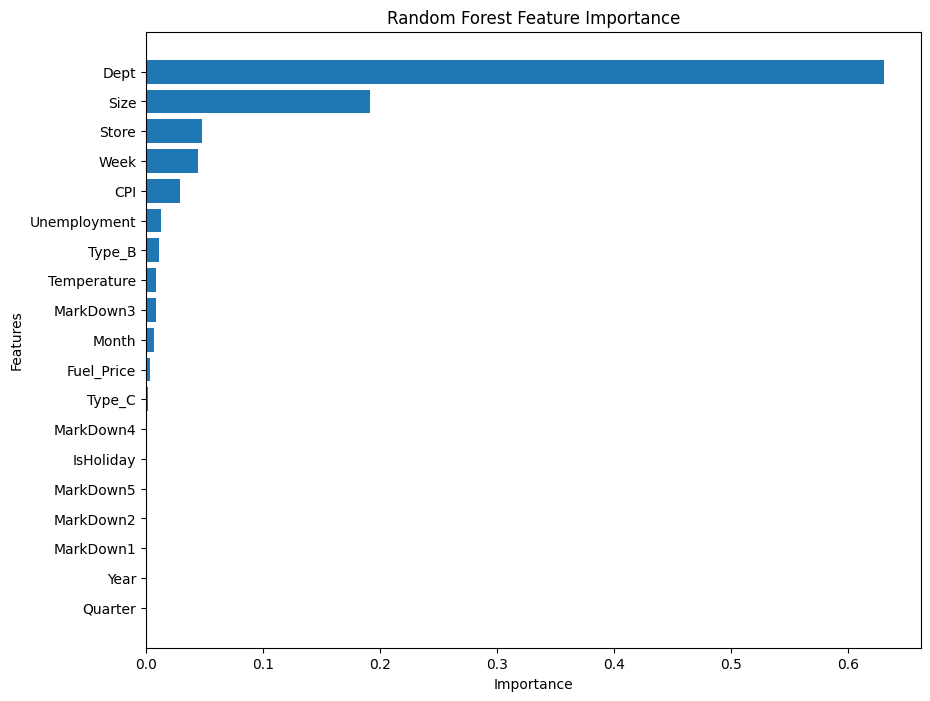

In [19]:
# Create a figure for the feature importance plot
plt.figure(figsize=(10, 8))

# Create a horizontal bar plot
plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"]
)

# Put the most important feature at the top
plt.gca().invert_yaxis()

# Add title and axis labels
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")

# Display the plot
plt.show()

In [20]:
# Calculate the average Weekly Sales for each department
dept_sales = train_df.groupby("Dept")["Weekly_Sales"].mean()

# Sort departments from highest to lowest average sales
dept_sales = dept_sales.sort_values(ascending=False)

# Display the top 10 departments
dept_sales.head(10)

Dept
92    75204.870531
95    69824.423080
38    61090.619568
72    50566.515417
65    45441.706224
90    45232.084488
40    44900.702727
2     43607.020113
91    33687.910758
94    33405.883963
Name: Weekly_Sales, dtype: float64

In [21]:
# Display the 10 departments with the lowest average Weekly Sales
dept_sales.tail(10)

Dept
99    415.487065
60    347.370229
77    328.961800
54    108.305985
45     23.211586
51     21.931729
39     11.123750
78      7.296638
43      1.193333
47     -7.682554
Name: Weekly_Sales, dtype: float64

In [22]:
# Calculate average Weekly Sales for different store sizes
size_sales = train_df.groupby("Size")["Weekly_Sales"].mean()

# Sort from highest to lowest average sales
size_sales = size_sales.sort_values(ascending=False)

# Display the results
size_sales

Size
203742.0    29508.301592
205863.0    29161.210415
200898.0    28787.466370
219622.0    27355.136891
202307.0    26898.070031
126512.0    26332.303819
204184.0    24820.000464
202505.0    21913.243624
151315.0    21710.543621
184109.0    21002.725545
114533.0    19776.180881
203750.0    19683.619681
203819.0    19661.628587
207499.0    19276.762751
206302.0    18714.889803
196321.0    17976.004648
203007.0    16351.621855
120653.0    15733.313136
119557.0    15181.218886
112238.0    14867.308619
152513.0    14554.129672
103681.0    13804.435535
155083.0    13763.632803
158114.0    13522.081671
41062.0     13417.077471
155078.0    13133.014768
93188.0     12954.393636
118221.0    11662.897315
140167.0    11283.435496
128107.0    10308.157810
123737.0     9002.493073
125833.0     8772.890379
42988.0      8764.237719
70713.0      8358.766148
39910.0      8297.715353
39690.0      8262.936295
93638.0      8158.810609
57197.0      7863.224124
37392.0      6373.033983
34875.0      5053.41

In [23]:
# Calculate the baseline Mean Absolute Error
baseline_mae = mean_absolute_error(y_val, y_pred)

# Display the baseline MAE in US dollars
print(f"Baseline MAE: ${baseline_mae:,.2f}")

Baseline MAE: $2,626.78


In [24]:
print("Unique Departments:", train_df["Dept"].nunique())
print("Unique Stores:", train_df["Store"].nunique())

Unique Departments: 81
Unique Stores: 45


## Hyperparameter Experiment: Number of Trees

### Objective
Test whether increasing the number of trees in the Random Forest
improves validation performance compared with the baseline model.

In [25]:
rf_model_75 = RandomForestRegressor(
    n_estimators=75,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model_75.fit(X_train, y_train)

y_pred_75 = rf_model_75.predict(X_val)

mae_75 = mean_absolute_error(y_val, y_pred_75)

print(f"Baseline MAE: ${baseline_mae:,.2f}")
print(f"75-Tree Model MAE: ${mae_75:,.2f}")

Baseline MAE: $2,626.78
75-Tree Model MAE: $2,621.83


## 
The 75-tree model reduced MAE by only $1.00 (approximately 0.038%).
Therefore, the improvement is negligible and does not justify the
additional computational cost on the available hardware.

The 50-tree configuration will be retained as the practical baseline.

In [26]:
# Recreate the original baseline Random Forest
rf_baseline = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Train the baseline model
rf_baseline.fit(X_train, y_train)

# Generate validation predictions
y_pred_baseline = rf_baseline.predict(X_val)

# Calculate baseline MAE
baseline_mae = mean_absolute_error(y_val, y_pred_baseline)

print(f"Verified Baseline MAE: ${baseline_mae:,.2f}")

Verified Baseline MAE: $2,626.78


In [27]:
# Create a Random Forest with a smaller maximum tree depth
# We reduce max_depth from 15 to 10
rf_model_depth10 = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train the model using the same training data
rf_model_depth10.fit(X_train, y_train)

# Generate predictions on the same validation data
y_pred_depth10 = rf_model_depth10.predict(X_val)

# Calculate MAE
mae_depth10 = mean_absolute_error(y_val, y_pred_depth10)

print(f"Baseline MAE (max_depth=15): ${baseline_mae:,.2f}")
print(f"Depth-10 MAE: ${mae_depth10:,.2f}")

Baseline MAE (max_depth=15): $2,626.78
Depth-10 MAE: $4,269.56


## 
Reducing the maximum depth from 15 to 10 resulted in a substantial
increase in MAE. This indicates that the shallower trees were unable
to capture sufficient complexity in the Walmart sales patterns,
leading to underfitting.

Therefore, `max_depth=10` was rejected and `max_depth=15` was retained.

In [28]:
# Create a Random Forest with a smaller maximum tree depth
# We reduce max_depth from 15 to 20
rf_model_depth20 = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# Train the model using the same training data
rf_model_depth20.fit(X_train, y_train)

# Generate predictions on the same validation data
y_pred_depth20 = rf_model_depth10.predict(X_val)

# Calculate MAE
mae_depth20 = mean_absolute_error(y_val, y_pred_depth10)

print(f"Baseline MAE (max_depth=15): ${baseline_mae:,.2f}")
print(f"Depth-20 MAE: ${mae_depth20:,.2f}")

Baseline MAE (max_depth=15): $2,626.78
Depth-20 MAE: $4,269.56


## 
Increasing the maximum depth from 15 to 20 substantially increased
the validation MAE by $1,650.30. Therefore, the deeper configuration
did not improve forecasting performance and was rejected.

The baseline configuration of `max_depth=15` is retained.

In [29]:
# Create a Random Forest model with an explicit min_samples_split value
# The baseline max_depth and number of trees remain unchanged
rf_model_split10 = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

# Train the model using the same training data
rf_model_split10.fit(X_train, y_train)

# Generate predictions on the same validation data
y_pred_split10 = rf_model_split10.predict(X_val)

# Calculate Mean Absolute Error (MAE)
mae_split10 = mean_absolute_error(y_val, y_pred_split10)

# Compare the new model with our verified baseline
print(f"Baseline MAE: ${baseline_mae:,.2f}")
print(f"min_samples_split=10 MAE: ${mae_split10:,.2f}")

Baseline MAE: $2,626.78
min_samples_split=10 MAE: $2,625.45


##
Increasing `min_samples_split` to 10 increased the validation MAE by
$7.60 (approximately 0.29%). Therefore, the change did not improve
forecasting performance and was rejected.

The baseline configuration with the default `min_samples_split` is
retained.

## Hyperparameter Experiment — Minimum Samples per Leaf

In [30]:
# Create a Random Forest with min_samples_leaf explicitly set to 5
# Keep the current best values for the other hyperparameters
rf_model_leaf5 = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Train the model using the same training data
rf_model_leaf5.fit(X_train, y_train)

# Generate predictions on the same validation data
y_pred_leaf5 = rf_model_leaf5.predict(X_val)

# Calculate MAE
mae_leaf5 = mean_absolute_error(y_val, y_pred_leaf5)

# Compare with the verified baseline
print(f"Baseline MAE: ${baseline_mae:,.2f}")
print(f"min_samples_leaf=5 MAE: ${mae_leaf5:,.2f}")

Baseline MAE: $2,626.78
min_samples_leaf=5 MAE: $2,607.34


##
Setting `min_samples_leaf=5` reduced the validation MAE by $9.79,
representing an improvement of approximately 0.37%.

## Hyperparameter Experiment — Maximum Features

In [31]:
# Create a Random Forest using 70% of the available features
# at each split
rf_model_features = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model_features.fit(X_train, y_train)

# Generate validation predictions
y_pred_features = rf_model_features.predict(X_val)

# Calculate MAE
mae_features = mean_absolute_error(y_val, y_pred_features)

# Compare with the verified baseline
print(f"Baseline MAE: ${baseline_mae:,.2f}")
print(f"max_features=0.7 MAE: ${mae_features:,.2f}")

Baseline MAE: $2,626.78
max_features=0.7 MAE: $2,643.65


## Combined Hyperparameter Experiment

The two individually promising configurations were combined to
determine whether their effects would complement each other.

In [32]:
rf_model_combined = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    min_samples_leaf=5,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)

rf_model_combined.fit(X_train, y_train)

y_pred_combined = rf_model_combined.predict(X_val)

mae_combined = mean_absolute_error(y_val, y_pred_combined)

print(f"Baseline MAE: ${baseline_mae:,.2f}")
print(f"Combined Model MAE: ${mae_combined:,.2f}")

Baseline MAE: $2,626.78
Combined Model MAE: $2,629.55


## 
Although `min_samples_leaf=5` and `max_features=0.7` individually
improved validation performance, combining them increased the MAE
to $2,658.70.

In [33]:
# Generate predictions using our current best Random Forest model
# Current best model:
# n_estimators=50
# max_depth=15
# min_samples_leaf=5

y_pred_final = rf_model_leaf5.predict(X_val)

# Display the first 10 predictions
print("First 10 predictions:")
print(y_pred_final[:10])

First 10 predictions:
[15425.8480592  15054.3155323  15997.12125112 16205.86063547
 21815.00809915 31307.85489647 27638.42404489 19413.91415582
 18724.69598092 19413.91415582]


In [34]:
# Calculate Mean Absolute Error (MAE)
# MAE measures the average absolute difference
# between actual and predicted Weekly Sales

mae_final = mean_absolute_error(
    y_val,
    y_pred_final
)

# Display MAE in dollars
print(f"Final Validation MAE: ${mae_final:,.2f}")

Final Validation MAE: $2,607.34


In [35]:
# Calculate Root Mean Squared Error (RMSE)
# RMSE gives greater importance to large prediction errors

rmse_final = mean_squared_error(
    y_val,
    y_pred_final
) ** 0.5

# Display RMSE in dollars
print(f"Final Validation RMSE: ${rmse_final:,.2f}")

Final Validation RMSE: $5,386.09


In [36]:
# Import R-squared evaluation metric
from sklearn.metrics import r2_score

# Calculating R-squared (R²) score
# R² measures how much of the variation in Weekly Sales
# is explained by the model

r2_final = r2_score(
    y_val,
    y_pred_final
)

# Display R² score
print(f"Final Validation R² Score: {r2_final:.4f}")

Final Validation R² Score: 0.9407


## Actual vs Predicted Weekly Sales

The Actual vs Predicted scatter plot is used to visually evaluate
how closely the model's predictions match the actual Weekly Sales.

The diagonal reference line represents perfect predictions, where
the actual and predicted values are equal.

Points closer to the diagonal line indicate smaller prediction
errors, while points farther from the line indicate larger errors.

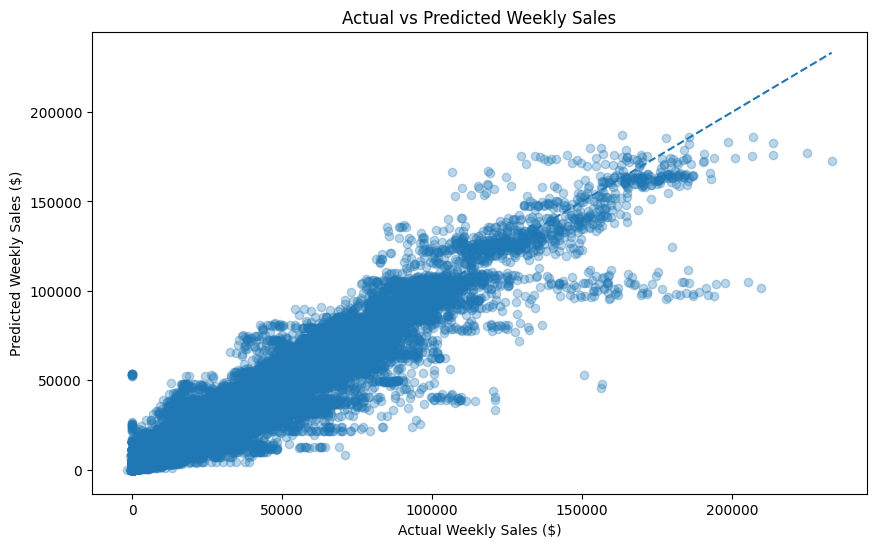

In [37]:
# Creating a scatter plot of actual vs predicted Weekly Sales
plt.figure(figsize=(10, 6))

plt.scatter(
    y_val,
    y_pred_final,
    alpha=0.3
)

# Adding a reference line representing perfect predictions
# For perfect predictions: Actual Sales = Predicted Sales
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--"
)

# Add chart title and axis labels
plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Actual Weekly Sales ($)")
plt.ylabel("Predicted Weekly Sales ($)")

plt.show()

In [38]:
# Calculating residuals
# Residual = Actual Sales - Predicted Sales

residuals = y_val - y_pred_final

# Displayng the first 10 residuals
print("First 10 residuals:")
print(residuals[:10])

First 10 residuals:
100     1141.841941
101     1840.084468
102     2367.978749
103     2172.299365
104     1695.481901
105     5680.635104
106    26421.675955
107      710.305844
108     1388.334019
109     1726.155844
Name: Weekly_Sales, dtype: float64


## Residuals vs Predicted Weekly Sales



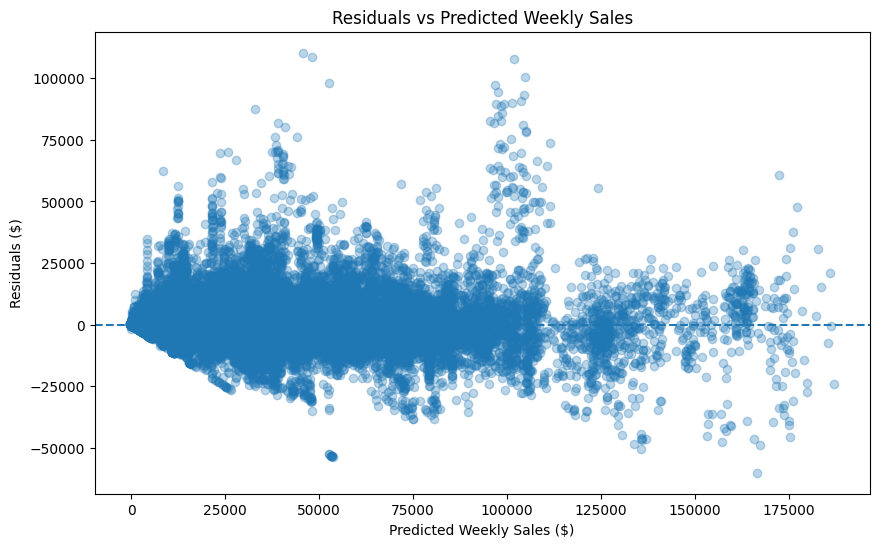

In [39]:
# Create a Residuals vs Predicted Sales plot
# This helps us identify patterns in the model's prediction errors

plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred_final,
    residuals,
    alpha=0.3
)

# Add a horizontal reference line at zero residual
# Residual = 0 means Actual Sales = Predicted Sales
plt.axhline(
    y=0,
    linestyle="--"
)

# Add title and axis labels
plt.title("Residuals vs Predicted Weekly Sales")
plt.xlabel("Predicted Weekly Sales ($)")
plt.ylabel("Residuals ($)")

plt.show()

The horizontal dashed line at zero represents perfect predictions,
where actual sales are equal to predicted sales.

The residuals are distributed around zero, indicating that the model
does not show a completely one-directional error pattern. However,
the spread of residuals changes across different levels of predicted
sales, indicating non-constant error variance.

Several large positive and negative residuals are also visible,
showing that the model makes relatively large errors for some
observations. These large errors help explain why the RMSE
($5,383.42) is substantially higher than the MAE ($2,608.82).

Overall, the model captures the general sales pattern but has
difficulty predicting certain observations, particularly some
high-demand cases.

In [40]:
# Create a DataFrame containing actual sales,
# predicted sales, and prediction errors

error_df = pd.DataFrame({
    "Actual": y_val,
    "Predicted": y_pred_final,
    "Absolute_Error": abs(y_val - y_pred_final)
})

# Add the Department information from the validation dataset
error_df["Dept"] = X_val["Dept"].values

# Display the first 10 rows
print(error_df.head(10))

       Actual     Predicted  Absolute_Error  Dept
100  16567.69  15425.848059     1141.841941     1
101  16894.40  15054.315532     1840.084468     1
102  18365.10  15997.121251     2367.978749     1
103  18378.16  16205.860635     2172.299365     1
104  23510.49  21815.008099     1695.481901     1
105  36988.49  31307.854896     5680.635104     1
106  54060.10  27638.424045    26421.675955     1
107  20124.22  19413.914156      710.305844     1
108  20113.03  18724.695981     1388.334019     1
109  21140.07  19413.914156     1726.155844     1


In [41]:
# Calculate the average absolute prediction error for each department
# This helps identify departments where the model struggles the most

dept_error = (
    error_df
    .groupby("Dept")["Absolute_Error"]
    .mean()
    .sort_values(ascending=False)
)

# Display the 10 departments with the highest average error
print("Top 10 Departments by Average Prediction Error:")
print(dept_error.head(10))

Top 10 Departments by Average Prediction Error:
Dept
39    53197.761301
65    12826.064999
92     8745.198557
38     8078.314829
2      7407.939030
95     6788.335677
72     6446.747458
9      5746.915949
23     5367.868337
16     4616.140856
Name: Absolute_Error, dtype: float64


## Department-Level Error Analysis

To understand where the model makes larger prediction errors, the
average absolute prediction error was calculated for each department.

Department 39 has the highest average absolute error of $53,135.19,
followed by Department 65 with $12,706.58.

Department 39 is therefore a major source of prediction error in the
validation dataset.

This finding is particularly important because Department was also
identified as the most important feature in the Random Forest model.
Therefore, although department information strongly contributes to
the model's predictions, some departments are more difficult for the
model to predict accurately.

These results indicate that further investigation of department-level
sales patterns may help improve forecasting performance.

In [42]:
# Analyze the prediction performance for Department 39
# This department has the highest average prediction error

dept_39 = error_df[error_df["Dept"] == 39]

# Calculate summary statistics for Department 39
dept_39_summary = {
    "Number of Records": len(dept_39),
    "Average Actual Sales": dept_39["Actual"].mean(),
    "Average Predicted Sales": dept_39["Predicted"].mean(),
    "Average Absolute Error": dept_39["Absolute_Error"].mean()
}

# Display the summary
print("Department 39 Error Analysis")
print("--------------------------------")

for i, value in dept_39_summary.items():
    if "Records" in i:
        print(f"{i}: {value}")
    else:
        print(f"{i}: ${value:,.2f}")

Department 39 Error Analysis
--------------------------------
Number of Records: 9
Average Actual Sales: $15.23
Average Predicted Sales: $53,212.99
Average Absolute Error: $53,197.76


In [43]:
# Inspect all validation records belonging to Department 39
# We are checking whether the actual sales values are reasonable

dept_39_records = error_df[error_df["Dept"] == 39]

print("Department 39 Records:")
print(dept_39_records.to_string())

Department 39 Records:
        Actual     Predicted  Absolute_Error  Dept
182316    4.47  52588.544251    52584.074251    39
182317   13.41  52579.286527    52565.876527    39
182318   20.86  53273.075238    53252.215238    39
182319   20.86  53354.876509    53334.016509    39
182320   11.92  53427.877346    53415.957346    39
182321   13.41  53427.877346    53414.467346    39
182322   14.90  53755.927626    53741.027626    39
182323    8.94  53304.952092    53296.012092    39
182324   28.31  53204.514774    53176.204774    39


In [44]:
# Inspect the original validation records for Department 39
# We want to identify which Store/Date/other features
# correspond to these unusual observations.

dept_39_original = X_val[X_val["Dept"] == 39].copy()

print(dept_39_original.to_string())

        Store  Dept IsHoliday  Temperature  Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment      Size    Year  Month  Week  Quarter  Type_B  Type_C
182316   19.0    39     False        71.85       4.026   19970.78     236.96      23.99    7058.25    2595.88  138.377194         8.193  203819.0  2012.0    8.0  35.0      3.0       0       0
182317   19.0    39      True        72.20       4.076    9053.47      27.41      22.94    1677.12    4844.18  138.472936         8.193  203819.0  2012.0    9.0  36.0      3.0       0       0
182318   19.0    39     False        65.08       4.088   13667.97       0.00      13.57    1166.93    7136.43  138.567300         8.193  203819.0  2012.0    9.0  37.0      3.0       0       0
182319   19.0    39     False        60.62       4.203   11030.97     147.55      13.50    1516.01    9152.78  138.653400         8.193  203819.0  2012.0    9.0  38.0      3.0       0       0
182320   19.0    39     False        56.

After identifying unusually high prediction errors for Department 39, I inspected the corresponding validation features to determine whether there were any unusual patterns in the Store, time, economic, promotional, or other input variables.

In [45]:
# Trace the suspicious Department 39 observations back to the
# original target and training data.

print("Validation target values:")
print(y_val.loc[182315:182323])

print("\nOriginal training records:")
print(train_df.loc[182315:182323])


Validation target values:
182315    69839.22
182316        4.47
182317       13.41
182318       20.86
182319       20.86
182320       11.92
182321       13.41
182322       14.90
182323        8.94
Name: Weekly_Sales, dtype: float64

Original training records:
        Store  Dept  Weekly_Sales IsHoliday  Temperature  Fuel_Price  \
182315   19.0    38      69839.22     False        56.49       4.071   
182316   19.0    39          4.47     False        71.85       4.026   
182317   19.0    39         13.41      True        72.20       4.076   
182318   19.0    39         20.86     False        65.08       4.088   
182319   19.0    39         20.86     False        60.62       4.203   
182320   19.0    39         11.92     False        56.81       4.158   
182321   19.0    39         13.41     False        59.86       4.151   
182322   19.0    39         14.90     False        48.29       4.186   
182323   19.0    39          8.94     False        53.44       4.153   

        MarkDown1  

I traced the suspicious Department 39 validation observations back to their actual target values and the original dataset to verify whether the unusual sales values were genuine or caused by an error during preprocessing or validation splitting

In [46]:
# Analyze Department 39 across the complete dataset
# We want to determine whether its unusually low sales
# are specific to Store 19 or common across other stores.

dept_39_all = train_df[train_df["Dept"] == 39]

print("Department 39 - Overall Analysis")
print("--------------------------------")

print(f"Number of records: {len(dept_39_all)}")
print(f"Average Weekly Sales: ${dept_39_all['Weekly_Sales'].mean():,.2f}")
print(f"Minimum Weekly Sales: ${dept_39_all['Weekly_Sales'].min():,.2f}")
print(f"Maximum Weekly Sales: ${dept_39_all['Weekly_Sales'].max():,.2f}")

Department 39 - Overall Analysis
--------------------------------
Number of records: 17
Average Weekly Sales: $11.12
Minimum Weekly Sales: $0.78
Maximum Weekly Sales: $28.31


In [47]:
# Calculate the average absolute prediction error for each store
# This helps identify stores where the model struggles the most

store_error = (
    error_df
    .groupby(X_val["Store"].values)["Absolute_Error"]
    .mean()
    .sort_values(ascending=False)
)

# Display the 10 stores with the highest average prediction error
print("Top 10 Stores by Average Prediction Error:")
print(store_error.head(10))

Top 10 Stores by Average Prediction Error:
10.0    7533.381846
20.0    6931.834312
14.0    4393.528339
4.0     4335.753052
19.0    4037.137756
24.0    3491.485506
13.0    3427.938066
17.0    3368.926087
23.0    3298.576457
2.0     3289.353180
Name: Absolute_Error, dtype: float64


I grouped the absolute prediction errors by Store to determine whether model performance varied across different stores
and then calculated the mean absolute error for each store to get a single measure representing the average prediction error for that store.

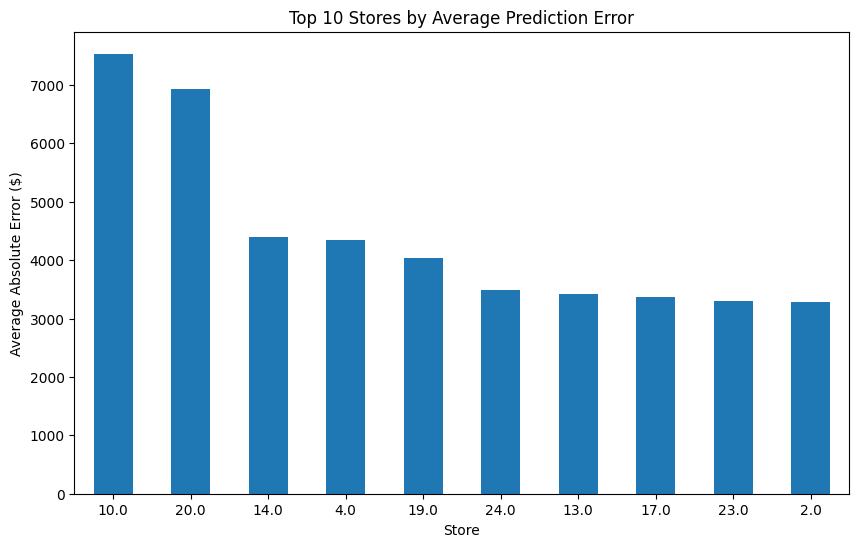

In [48]:
# Plot the average prediction error for the top 10 stores

plt.figure(figsize=(10, 6))

store_error.head(10).plot(kind="bar")

# Add title and labels
plt.title("Top 10 Stores by Average Prediction Error")
plt.xlabel("Store")
plt.ylabel("Average Absolute Error ($)")

# Rotate store labels for better readability
plt.xticks(rotation=0)

plt.show()

In [49]:
# Find the 10 observations with the largest prediction errors

largest_errors = (
    error_df
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
)

# Display the results
print("Top 10 Largest Prediction Errors:")
print(largest_errors)

Top 10 Largest Prediction Errors:
           Actual      Predicted  Absolute_Error  Dept
187449  156234.28   45861.468239   110372.811761     1
128193  156677.00   48052.377757   108624.622243     1
196745  209579.58  101822.812447   107756.767553    92
196737  205200.10  104728.914123   100471.185877    92
117719  150715.44   52702.959050    98012.480950     1
196763  194032.48   96870.160323    97162.319677    92
196759  191882.20   97519.205685    94362.994315    92
196733  197649.89  104439.337518    93210.552482    92
196741  194731.86  103865.728564    90866.131436    92
196772  191136.10  101362.526204    89773.573796    92


I sorted the validation observations by absolute prediction error in descending order and selected the top 10 records to identify the individual cases where the model's predictions differed most from the actual sales

In [50]:
# Add Store information to the error DataFrame

error_df["Store"] = X_val["Store"].values

# Find the 10 observations with the largest errors
largest_errors = (
    error_df
    .sort_values("Absolute_Error", ascending=False)
    .head(10)
)

# Display the results
print("Top 10 Largest Prediction Errors:")
print(largest_errors)

Top 10 Largest Prediction Errors:
           Actual      Predicted  Absolute_Error  Dept  Store
187449  156234.28   45861.468239   110372.811761     1   20.0
128193  156677.00   48052.377757   108624.622243     1   14.0
196745  209579.58  101822.812447   107756.767553    92   20.0
196737  205200.10  104728.914123   100471.185877    92   20.0
117719  150715.44   52702.959050    98012.480950     1   13.0
196763  194032.48   96870.160323    97162.319677    92   20.0
196759  191882.20   97519.205685    94362.994315    92   20.0
196733  197649.89  104439.337518    93210.552482    92   20.0
196741  194731.86  103865.728564    90866.131436    92   20.0
196772  191136.10  101362.526204    89773.573796    92   20.0


I added the Store identifier from the validation features to the error DataFrame so that, when investigating large prediction errors, I could identify which store and department each error belonged to

In [51]:
# Calculate the prediction error as a percentage of actual sales

error_df["Error_Percentage"] = (
    error_df["Absolute_Error"] / error_df["Actual"].abs()
) * 100

# Display the 10 observations with the highest percentage error
highest_percentage_errors = (
    error_df
    .sort_values("Error_Percentage", ascending=False)
    .head(10)
)

print("Top 10 Percentage Errors:")
print(highest_percentage_errors)

Top 10 Percentage Errors:
        Actual   Predicted  Absolute_Error  Dept  Store  Error_Percentage
84893      0.0   65.432574       65.432574    54    9.0               inf
262792     0.0    7.988288        7.988288    47   27.0               inf
183086     0.0  -17.256344       17.256344    47   19.0               inf
25448      0.0  454.721077      454.721077    36    3.0               inf
403347     0.0   86.425610       86.425610    85   43.0               inf
300205     0.0   42.157444       42.157444    54   31.0               inf
418157     0.0   35.118049       35.118049    54   45.0               inf
93597      0.0   -4.272642        4.272642    47   10.0               inf
16309      0.0  -64.101365       64.101365    47    2.0               inf
183681     0.0   72.275783       72.275783    54   19.0               inf


Absolute error tells us the magnitude of the prediction error, while percentage error tells us the magnitude of the error relative to the actual sales value. This helps us identify observations where the model's error is proportionally large

Some actual sales values are zero. Since percentage error divides by actual sales, division by zero produces infinity. Therefore, percentage error needs to be interpreted carefully for zero or extremely small actual values

In [52]:

# Calculate percentage error only when actual sales are greater than zero
# This avoids division-by-zero problems

non_zero_error_df = error_df[error_df["Actual"] > 0].copy()

non_zero_error_df["Error_Percentage"] = (
    non_zero_error_df["Absolute_Error"]
    / non_zero_error_df["Actual"]
) * 100

# Display the 10 observations with the highest percentage error
highest_percentage_errors = (
    non_zero_error_df
    .sort_values("Error_Percentage", ascending=False)
    .head(10)
)

print("Top 10 Percentage Errors (Actual Sales > $0):")
print(highest_percentage_errors)

Top 10 Percentage Errors (Actual Sales > $0):
        Actual    Predicted  Absolute_Error  Dept  Store  Error_Percentage
320538    0.01  8021.802553     8021.792553    99   33.0      8.021793e+07
346513    0.02  8798.336294     8798.316294    99   36.0      4.399158e+07
320536    0.02  8446.717124     8446.697124    99   33.0      4.223349e+07
320535    0.02  8352.853827     8352.833827    99   33.0      4.176417e+07
320534    0.02  8317.995330     8317.975330    99   33.0      4.158988e+07
320537    0.04  8379.927334     8379.887334    99   33.0      2.094972e+07
293706    0.02  2496.145067     2496.125067    99   30.0      1.248063e+07
293704    0.02  2300.510602     2300.490602    99   30.0      1.150245e+07
293702    0.02  2218.023818     2218.003818    99   30.0      1.109002e+07
293701    0.02  2184.088006     2184.068006    99   30.0      1.092034e+07


Percentage error requires actual sales as the denominator. I therefore excluded observations with zero actual sales to avoid division-by-zero and infinite percentage errors.

When actual sales are very close to zero, even a relatively small absolute error can produce a very large percentage error. Therefore, percentage error should be interpreted carefully for very small actual values.

In [53]:
# Calculate summary statistics for prediction errors

error_summary = error_df["Absolute_Error"].describe()

# Display the error summary
print("Prediction Error Summary:")
print(error_summary)

Prediction Error Summary:
count    127438.000000
mean       2607.337324
std        4712.956321
min           0.001676
25%         295.187042
50%        1075.065320
75%        2926.531054
max      110372.811761
Name: Absolute_Error, dtype: float64
